<a href="https://colab.research.google.com/github/LCCISNEROS/TALENTO-TECH/blob/main/experiencia/M2_U2_L2_Ac4_Redes_Neuronales.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [47]:
import keras
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [48]:
# cargar el conjunto de datos MNIST
mnist = keras.datasets.mnist

# cargue la divisiòn de entrenamiento y prueba del conjunto de datos MNIST
(training_images, training_labels), (test_images, test_labels) = mnist.load_data()


In [49]:
# Normalizar los valores de pixeles de tren y probar las imagenes
training_images = training_images / 255.0
test_images = test_images / 255.0

In [50]:
# Construir el modelo de clasificaciòn
model = keras.models.Sequential([
    # Agregar convoluciones y max pooling
    keras.layers.Conv2D(32, (3,3), activation="relu", input_shape=(28, 28, 1) ),
    keras.layers.MaxPooling2D(2, 2),
    # Agregar las mismas capas que antes
    keras.layers.Flatten(),
    keras.layers.Dense(128, activation="relu"),
    keras.layers.Dense(10, activation="softmax")])

model.summary()


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_2 (Conv2D)               │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 5408)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │       692,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 693,962 (2.65 MB)

 Trainable params: 693,962 (2.65 MB)

 Non-trainable params: 0 (0.00 B)

In [51]:
# predict usando la celda anterior
index = 1
classification = model.predict(test_images[index:index+1])

# Obtener el índice de la probabilidad más alta
predicted_digit = np.argmax(classification)

print(f"Salida de Softmax (probabilidades): {classification}")
print(f"El modelo predice que el dígito es: {predicted_digit}")
print(f"Etiqueta real: {test_labels[index]}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 314ms/step
Salida de Softmax (probabilidades): [[0.10980441 0.12583326 0.09448195 0.11539268 0.09867627 0.11207058
  0.07889477 0.08202614 0.09290752 0.08991235]]
El modelo predice que el dígito es: 1
Etiqueta real: 2


Aquí tienes la fórmula de la función Softmax en formato LaTeX:

La función Softmax para la $i$-ésima salida, dado un vector de entradas (logits) $z = [z_1, z_2, \dots, z_K]$, se define como:

$$ \sigma(z)_i = \frac{e^{z_i}}{\sum_{j=1}^K e^{z_j}} $$

Donde:
*   $\sigma(z)_i$ es la probabilidad de la clase $i$.
*   $e^{z_i}$ es la función exponencial aplicada al logit de la clase $i$.
*   $\sum_{j=1}^K e^{z_j}$ es la suma de las exponenciales de todos los logits para las $K$ clases.

In [52]:
import numpy as np

# Ejemplo de vector de entrada (logits)
logits = np.array([1.0, 2.0, 3.0])

# Paso 1: Calcular la exponencial de cada logit
exponenciales = np.exp(logits)
print(f"Exponenciales de los logits: {exponenciales}")

# Paso 2: Calcular la suma de las exponenciales
suma_exponenciales = np.sum(exponenciales)
print(f"Suma de las exponenciales: {suma_exponenciales}")

# Paso 3: Dividir cada exponencial por la suma para obtener las probabilidades (Softmax)
softmax_output = exponenciales / suma_exponenciales
print(f"Salida de Softmax (probabilidades): {softmax_output}")

# Verificar que la suma de las probabilidades es 1
print(f"Suma de las probabilidades de Softmax: {np.sum(softmax_output)}")

Exponenciales de los logits: [ 2.71828183  7.3890561  20.08553692]
Suma de las exponenciales: 30.19287485057736
Salida de Softmax (probabilidades): [0.09003057 0.24472847 0.66524096]
Suma de las probabilidades de Softmax: 1.0


In [53]:
# Copilar el modelo
model.compile(optimizer="adam",
              loss="sparse_categorical_crossentropy",
              metrics=["accuracy"])

In [54]:
# Entrenar el modelo
history = model.fit(training_images, training_labels, epochs=10)


Epoch 1/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - accuracy: 0.9139 - loss: 0.2995
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9842 - loss: 0.0506
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9920 - loss: 0.0271
Epoch 4/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9942 - loss: 0.0189
Epoch 5/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9958 - loss: 0.0127
Epoch 6/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.9968 - loss: 0.0096
Epoch 7/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9981 - loss: 0.0059
Epoch 8/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9975 - loss: 0.0071
Epoch 9/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9984 - loss: 0.0042
Epoch 10/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9988 - loss: 0.0039


<Axes: >

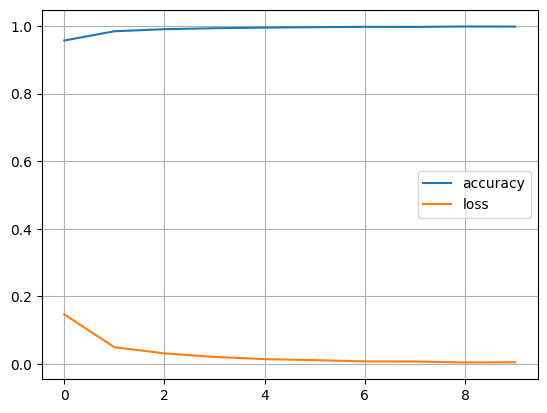

In [55]:
# Graficar el historial de entrenamiento
pd.DataFrame(history.history).plot(grid=True)


In [56]:
# Evaluar el modelo en el conjunto de entrenamiento
loss, accuracy = model.evaluate(training_images, training_labels)
print("Perdida en el conjunto de entrenamiento", loss)
print("Precisiòn en el conjunto de entrenamiento", accuracy)

# Evaluar el modelo con datos no vistos
loss, accuracy = model.evaluate(test_images, test_labels)
print("Perdida en el conjunto de prueba", loss)
print("Precisiòn en el conjunto de prueba", accuracy)

1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.9986 - loss: 0.0045
Perdida en el conjunto de entrenamiento 0.005627017002552748
Precisiòn en el conjunto de entrenamiento 0.9982333183288574
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9837 - loss: 0.0689
Perdida en el conjunto de prueba 0.057959698140621185
Precisiòn en el conjunto de prueba 0.98580002784729


In [57]:
# predict
index = 1
print(f"Label: {test_labels[index]}")
classification = model.predict(test_images[index:index+1])
print(f"Classification: /n {classification.reshape(-1,1)}")
print(test_labels[:30])

Label: 2
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 305ms/step
Classification: /n [[1.1978426e-09]
 [4.4711779e-08]
 [1.0000000e+00]
 [1.1651254e-14]
 [2.1878332e-18]
 [1.3040704e-17]
 [1.8819127e-10]
 [4.0577221e-18]
 [7.7495044e-14]
 [4.4240008e-13]]
[7 2 1 0 4 1 4 9 5 9 0 6 9 0 1 5 9 7 3 4 9 6 6 5 4 0 7 4 0 1]


In [58]:
print(test_labels[:30])

[7 2 1 0 4 1 4 9 5 9 0 6 9 0 1 5 9 7 3 4 9 6 6 5 4 0 7 4 0 1]


In [59]:
FIRST_IMAGE=3
SECOND_IMAGE=10
THIRD_IMAGE=25
print(test_labels[FIRST_IMAGE])
print(test_labels[SECOND_IMAGE])
print(test_labels[THIRD_IMAGE])

0
0
0


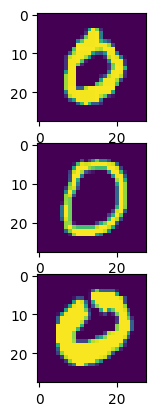

In [60]:
f, axarr = plt.subplots(3,1)
axarr[0].imshow(test_images[FIRST_IMAGE])
axarr[1].imshow(test_images[SECOND_IMAGE])
axarr[2].imshow(test_images[THIRD_IMAGE])

In [68]:
# Obtener las predicciones del modelo en el conjunto de prueba
predictions = model.predict(test_images)

# Convertir las predicciones (probabilidades) a clases predichas (el índice con la probabilidad más alta)
predicted_classes = np.argmax(predictions, axis=1)

# Generar el reporte de clasificaciòn
report = classification_report(test_labels, predicted_classes)

print(report)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
              precision    recall  f1-score   support

           0       1.00      0.99      0.99       980
           1       0.98      1.00      0.99      1135
           2       0.98      0.98      0.98      1032
           3       0.98      0.99      0.99      1010
           4       0.99      0.99      0.99       982
           5       0.99      0.97      0.98       892
           6       0.99      0.99      0.99       958
           7       0.98      0.98      0.98      1028
           8       0.97      0.99      0.98       974
           9       0.99      0.97      0.98      1009

    accuracy                           0.99     10000
   macro avg       0.99      0.99      0.99     10000
weighted avg       0.99      0.99      0.99     10000



In [69]:
from sklearn.metrics import classification_report

In [70]:
# Construir el modelo de clasificaciòn
model = keras.models.Sequential([
    # Agregar convoluciones y max pooling
    keras.layers.Conv2D(32, (3,3), activation="relu", input_shape=(28, 28, 1) ),
    keras.layers.MaxPooling2D(2, 2),
    # Agregar las mismas capas que antes
    keras.layers.Flatten(),
    keras.layers.Dense(128, activation="relu"),
    keras.layers.Dense(10, activation="softmax")])

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 5408)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 128)            │       692,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 693,962 (2.65 MB)

 Trainable params: 693,962 (2.65 MB)

 Non-trainable params: 0 (0.00 B)

In [71]:
# Copilar el modelo
model.compile(optimizer="adam",
              loss="sparse_categorical_crossentropy",
              metrics=["accuracy"])

In [72]:
# Entrenar el modelo
history = model.fit(training_images, training_labels, epochs=10)

Epoch 1/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - accuracy: 0.9156 - loss: 0.2888
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9836 - loss: 0.0521
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9910 - loss: 0.0289
Epoch 4/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9946 - loss: 0.0172
Epoch 5/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9964 - loss: 0.0112
Epoch 6/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9975 - loss: 0.0081
Epoch 7/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9982 - loss: 0.0055
Epoch 8/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9983 - loss: 0.0053
Epoch 9/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9995 - loss: 0.0022
Epoch 10/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9989 - loss: 0.0038


# Task
Genera el reporte de clasificación para el modelo entrenado utilizando las imágenes de prueba.

## Importar librerías

### Subtask:
Importar `classification_report` de `sklearn.metrics`.


**Reasoning**:
The subtask is to import the `classification_report` function from `sklearn.metrics`. This requires a single import statement.

